In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv("sales_data.csv")

In [3]:
df.head()

,Order_ID,Date,City,Sales_Rep,Product_Category,Product_Name,Season,Units_Sold,Unit_Price_USD,Discount_Percent,Revenue_USD,Customer_Rating,Delivery_Days,Payment_Method,Returned
0,1001,2025-01-05,Riyadh,Ahmed Alharbi,Computer,Laptop Pro 15,Winter,12.0,1500,5.0,17100.0,4.5,3.0,Credit Card,No
1,1002,2025-01-12,Jeddah,Sara Alqahtani,Audio,NoiseCancel X,Winter,25.0,250,10.0,5625.0,4.2,5.0,Cash,No
2,1003,2025-02-01,Dammam,Khalid Alshehri,Accessories,Smart Mouse,Winter,40.0,45,0.0,1800.0,4.0,4.0,Mada,No
3,1004,2025-02-14,Mecca,Reem Alotaibi,Computer,Gaming PC Ultra,Winter,5.0,3200,15.0,13600.0,4.8,7.0,Credit Card,No
4,1005,2025-03-03,Medina,Abdullah Almutairi,Audio,Bluetooth Speaker,Spring,60.0,120,5.0,6840.0,3.9,6.0,Cash,No


In [4]:
df.columns

Index(['Order_ID', 'Date', 'City', 'Sales_Rep', 'Product_Category',
       'Product_Name', 'Season', 'Units_Sold', 'Unit_Price_USD',
       'Discount_Percent', 'Revenue_USD', 'Customer_Rating', 'Delivery_Days',
       'Payment_Method', 'Returned'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          50 non-null     int64  
 1   Date              50 non-null     object 
 2   City              50 non-null     object 
 3   Sales_Rep         50 non-null     object 
 4   Product_Category  50 non-null     object 
 5   Product_Name      50 non-null     object 
 6   Season            50 non-null     object 
 7   Units_Sold        49 non-null     float64
 8   Unit_Price_USD    50 non-null     int64  
 9   Discount_Percent  49 non-null     float64
 10  Revenue_USD       49 non-null     float64
 11  Customer_Rating   48 non-null     float64
 12  Delivery_Days     49 non-null     float64
 13  Payment_Method    50 non-null     object 
 14  Returned          50 non-null     object 
dtypes: float64(5), int64(2), object(8)
memory usage: 6.0+ KB


### Data Prepation and Cleaning

In [6]:
# Count the number of missing (NaN) values in each column
df.isnull().sum()

Order_ID            0
Date                0
City                0
Sales_Rep           0
Product_Category    0
Product_Name        0
Season              0
Units_Sold          1
Unit_Price_USD      0
Discount_Percent    1
Revenue_USD         1
Customer_Rating     2
Delivery_Days       1
Payment_Method      0
Returned            0
dtype: int64

In [7]:
# Create list to store column names that contain missing values
nullcols = []

for i,v in df.isnull().sum().items():
    if(v > 0):
        nullcols.append(i)

print(nullcols)


['Units_Sold', 'Discount_Percent', 'Revenue_USD', 'Customer_Rating', 'Delivery_Days']


In [8]:
## Print the data type of columns with missing values
for i in df.columns:
    if i in nullcols:
        print(i , df[i].dtype)

Units_Sold float64
Discount_Percent float64
Revenue_USD float64
Customer_Rating float64
Delivery_Days float64


#### Customer_Rating


In [9]:
df["Customer_Rating"].unique()

array([4.5, 4.2, 4. , 4.8, 3.9, 4.1, 4.3, 4.6, 4.4, 4.9, 3.8, 4.7, 3.7,
       3.5, 3.6, 3.4, nan, 2.5, 5. , 1.8])

Replace missing values with 0 because a rating of 0 represents customers who did not leave a rating.

In [10]:
df["Customer_Rating"] = df["Customer_Rating"].fillna(0)


#### Delivery_Days

In [11]:
# Since delivery time depends on the city, identify the cities
# where Delivery_Days contains missing values.
city = df.loc[df["Delivery_Days"].isna(), "City"].values
city

array(['Jubail'], dtype=object)

In [12]:
df.loc[df["City"].isin(city), ["Delivery_Days","City"]]

,Delivery_Days,City
8,3.0,Jubail
18,3.0,Jubail
28,8.0,Jubail
38,5.0,Jubail
48,NaN,Jubail


In [13]:
Q1 = df["Delivery_Days"].quantile(0.25)
Q3 = df["Delivery_Days"].quantile(0.75)
IQR = Q3 - Q1

outliers = df.loc[(
    (df["Delivery_Days"] < Q1 - 1.5 * IQR) |
    (df["Delivery_Days"] > Q3 + 1.5 * IQR))
    & (df["City"].isin(city)),
    ["City", "Delivery_Days"]
]

outliers

,City,Delivery_Days


In [14]:
# No outliers were detected, so the missing values are filled
# with the mean Delivery_Days for each city.
df["Delivery_Days"] = df["Delivery_Days"].fillna(df.groupby("City")["Delivery_Days"].transform("mean"))

#### Discount_Percent

In [15]:
df["Discount_Percent"].unique()

array([ 5., 10.,  0., 15.,  8., 12.,  7., 20., 50., nan])

In [16]:
# Replace missing values with 0 since 0 represents no discount.
df["Discount_Percent"] = df["Discount_Percent"].fillna(0)

#### Revenue_USD & Unit_Price_USD

In [17]:
df.loc[
    df["Revenue_USD"].isna(),
    ["Revenue_USD", "Units_Sold", "Unit_Price_USD", "Discount_Percent"]
]

,Revenue_USD,Units_Sold,Unit_Price_USD,Discount_Percent
45,NaN,NaN,150,5.0


In [18]:
# Remove rows with missing Revenue_USD or Units_Sold,
# as these values depend on each other and cannot be reliably estimated.
df.dropna(subset=["Revenue_USD", "Units_Sold"], inplace=True)

#### Final Check

     

In [19]:
print("Remaining Missing Values:")
print(df.isna().sum())

Remaining Missing Values:
Order_ID            0
Date                0
City                0
Sales_Rep           0
Product_Category    0
Product_Name        0
Season              0
Units_Sold          0
Unit_Price_USD      0
Discount_Percent    0
Revenue_USD         0
Customer_Rating     0
Delivery_Days       0
Payment_Method      0
Returned            0
dtype: int64


### Histogram: Revenue Distribution

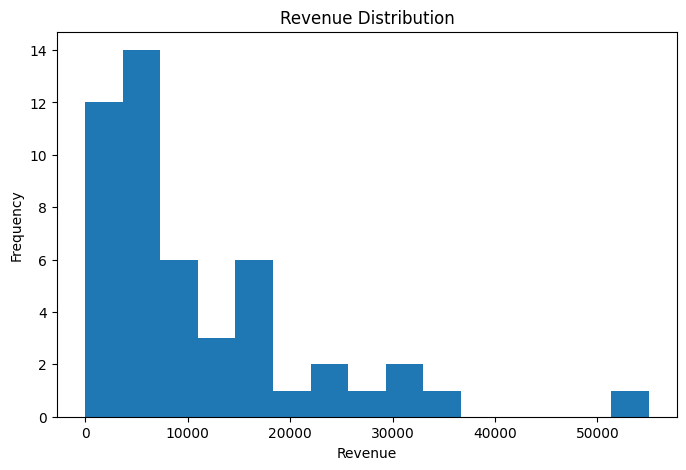

In [20]:
plt.figure(figsize=(8,5))
plt.hist(df["Revenue_USD"], bins = 15)
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

- The histogram shows that most orders generated low to medium revenue, mainly below **10,000 USD**.
- The distribution is **right-skewed**, indicating that high-revenue orders are relatively rare.
- A few outliers are present, with revenues exceeding **50,000 USD**.

### Boxplot: Revenue (Outliers Visible)

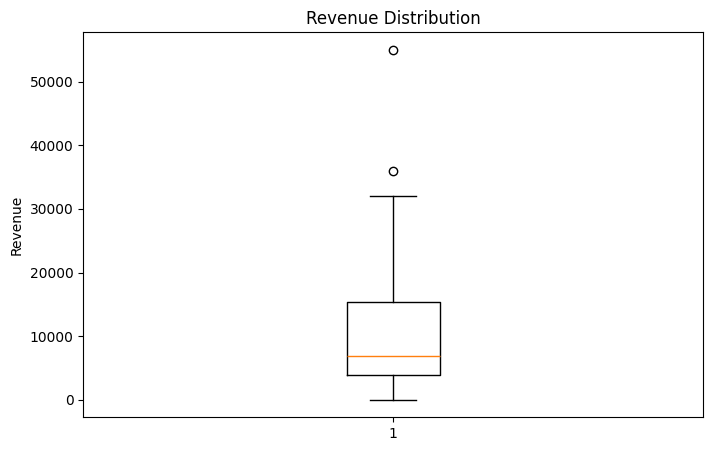

In [21]:
plt.figure(figsize=(8,5))
plt.boxplot(df["Revenue_USD"])
plt.title("Revenue Distribution")
plt.ylabel("Revenue")
plt.show()

- The median revenue is approximately **6,700 USD**.
- The middle 50% of revenues lie between **4,000 USD** and **15,000 USD**.
- Most revenue values fall within the normal range, extending up to approximately **32,000 USD**.
- A few high-value outliers are present, with revenues reaching around **36,000 USD** and **55,000 USD**.

### Scatter: Units VS Revenue

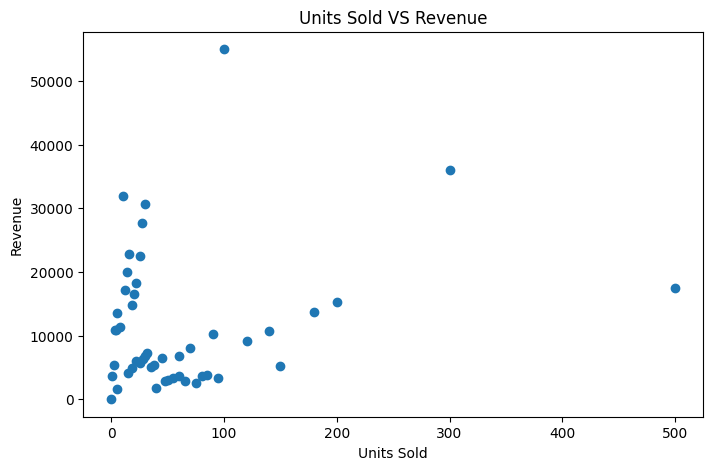

In [22]:
plt.figure(figsize=(8,5))
plt.scatter(df["Units_Sold"],df["Revenue_USD"])
plt.title("Units Sold VS Revenue")
plt.xlabel("Units Sold")
plt.ylabel("Revenue")
plt.show()

- The scatter plot shows a generally positive relationship between **Units Sold** and **Revenue**.
- Revenue tends to increase as the number of units sold increases.
- The relationship is not perfectly linear, likely due to differences in product prices and discounts.
- Most orders sold fewer than **100 units**, while a few high-value outliers generated exceptionally high revenue.

### Revenue by City

In [23]:
city_rev = df.groupby("City")["Revenue_USD"].sum().sort_values()
city_rev


City
Khobar    33624.0
Abha      36657.0
Medina    40370.0
Tabuk     40765.0
Hail      46177.5
Dammam    55131.4
Jubail    57170.0
Jeddah    74008.5
Mecca     81675.0
Riyadh    90317.0
Name: Revenue_USD, dtype: float64

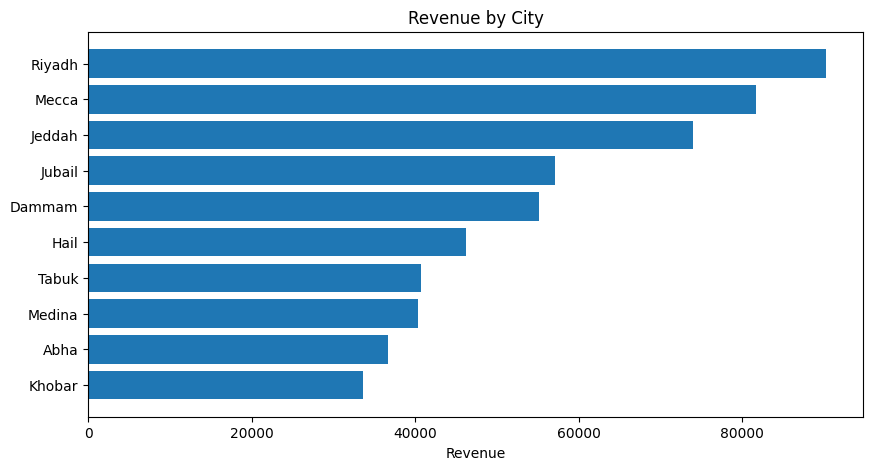

In [24]:
plt.figure(figsize=(10,5))
plt.barh(city_rev.index,city_rev.values)
plt.title("Revenue by City")
plt.xlabel("Revenue")
plt.show()

- **Riyadh** generated the **highest** total revenue, followed by **Mecca** and **Jeddah**.
- **Jubail** and **Dammam** achieved **similar** revenue levels, ranking in the middle.
- **Khobar** recorded the **lowest** total revenue among all cities.

### Revenue by Season

In [25]:
season_rev = df.groupby("Season")["Revenue_USD"].sum()
season_rev


Season
Autumn    105091.5
Spring     67393.5
Summer     89965.0
Winter    293445.4
Name: Revenue_USD, dtype: float64

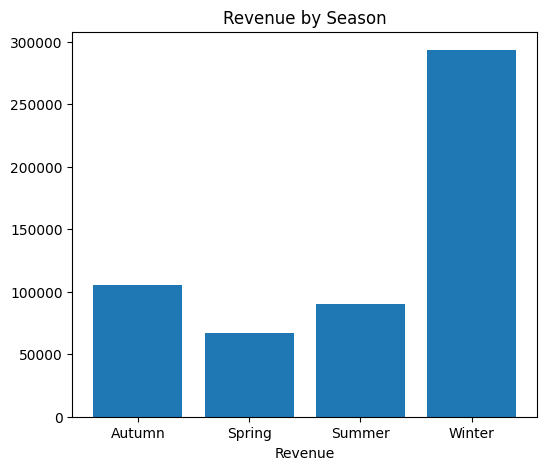

In [26]:
plt.figure(figsize=(6,5))
plt.bar(season_rev.index,season_rev.values)
plt.title("Revenue by Season")
plt.xlabel("Revenue")
plt.show()

- **Winter** generated the **highest** total revenue by a significant margin.
- **Autumn** ranked **second**, followed by **Summer**.
- **Spring** recorded the **lowest** total revenue.

### Revenue by Product Category

In [27]:
cat_rev = df.groupby("Product_Category")["Revenue_USD"].sum()
cat_rev


Product_Category
Accessories     70445.0
Audio          152461.4
Computer       332989.0
Name: Revenue_USD, dtype: float64

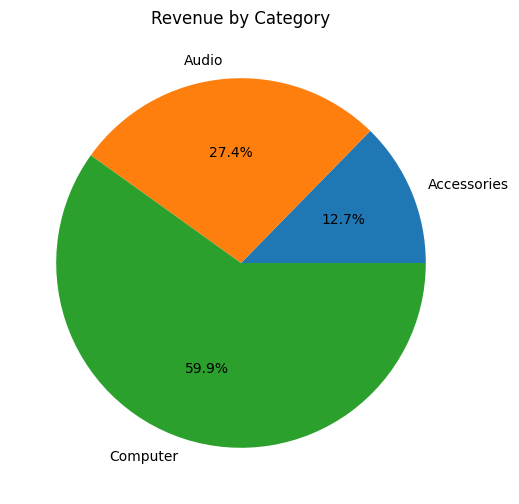

In [38]:
plt.figure(figsize=(6,6))
plt.pie(cat_rev.values,labels= cat_rev.index, autopct='%1.1f%%')
plt.title("Revenue by Category")
plt.show()

- **Computers** contributed the largest share of total revenue, accounting for **59.9%**.
- **Audio** ranked **second**, contributing **27.4%** of total revenue.
- **Accessories** generated the smallest share, representing **12.7%** of total revenue.

### Season × Category

In [29]:
pivot =  df.pivot_table(
    index = "Season",
    columns="Product_Category",
    values="Revenue_USD",
    aggfunc="sum",
    fill_value=0
)
pivot

Product_Category,Accessories,Audio,Computer
Season,,,
Autumn,14792.5,29982.0,60317.0
Spring,9037.5,12834.0,45522.0
Summer,11475.0,25740.0,52750.0
Winter,35140.0,83905.4,174400.0


In [30]:
bottom = np.zeros(len(pivot))

bottom

array([0., 0., 0., 0.])

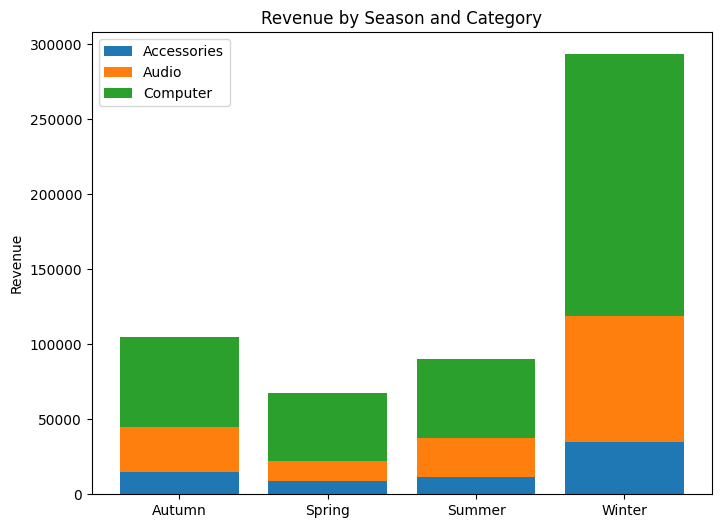

In [31]:
plt.figure(figsize=(8,6))
for col in pivot.columns:
    plt.bar(pivot.index, pivot[col], bottom=bottom , label=col)
    bottom += pivot[col]
plt.legend()
plt.title("Revenue by Season and Category")
plt.ylabel("Revenue")
plt.show()

### Correlation Heatmap

In [32]:
df.columns

Index(['Order_ID', 'Date', 'City', 'Sales_Rep', 'Product_Category',
       'Product_Name', 'Season', 'Units_Sold', 'Unit_Price_USD',
       'Discount_Percent', 'Revenue_USD', 'Customer_Rating', 'Delivery_Days',
       'Payment_Method', 'Returned'],
      dtype='object')

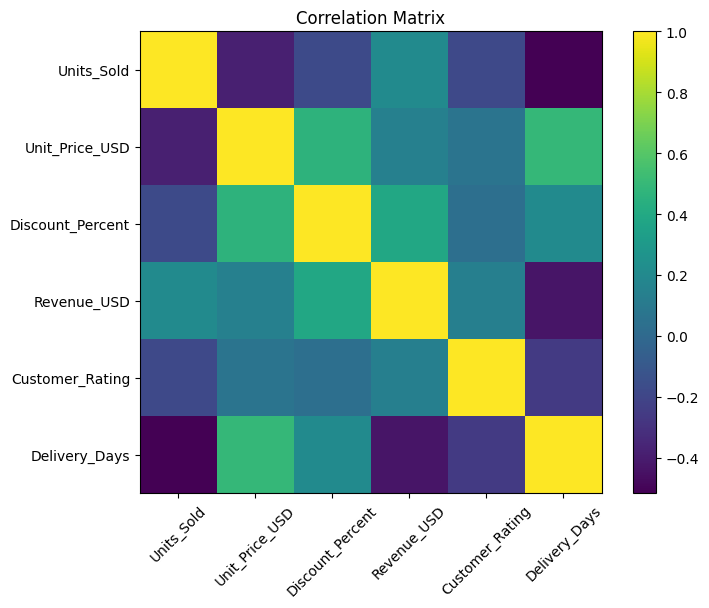

In [33]:
corr_cols = [
    'Units_Sold','Unit_Price_USD','Discount_Percent','Revenue_USD'
    ,'Customer_Rating','Delivery_Days'
]

corr = df[corr_cols].corr()
plt.figure(figsize=(8,6))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation = 45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()


### Revenue by Sales Rep

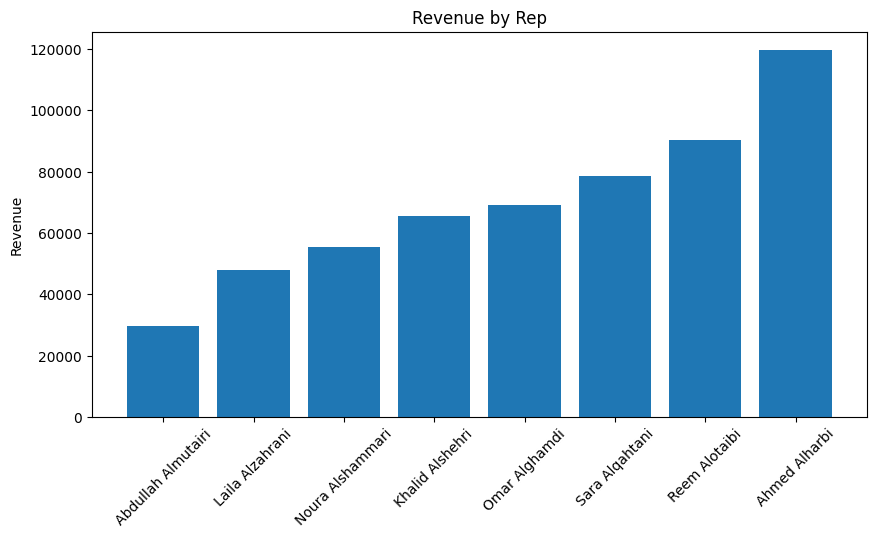

In [34]:
rep_rev = df.groupby("Sales_Rep")["Revenue_USD"].sum().sort_values()

plt.figure(figsize=(10,5))
plt.bar(rep_rev.index,rep_rev.values)
plt.xticks(rotation=45)
plt.title("Revenue by Rep")
plt.ylabel("Revenue")
plt.show()

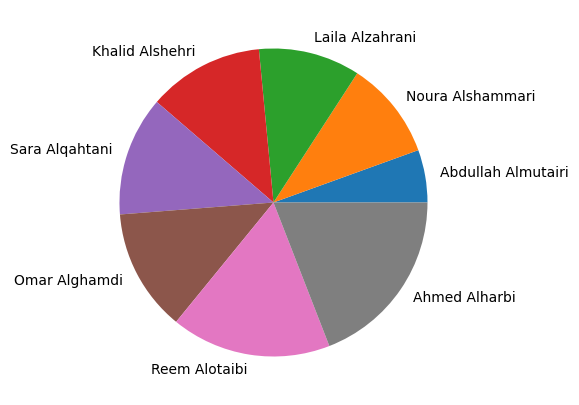

In [35]:
rep_rev_mean = df.groupby("Sales_Rep")["Revenue_USD"].mean().sort_values()

plt.figure(figsize=(10,5))
plt.pie(rep_rev_mean.values, labels=rep_rev_mean.index)

plt.show()

### Customer Rating

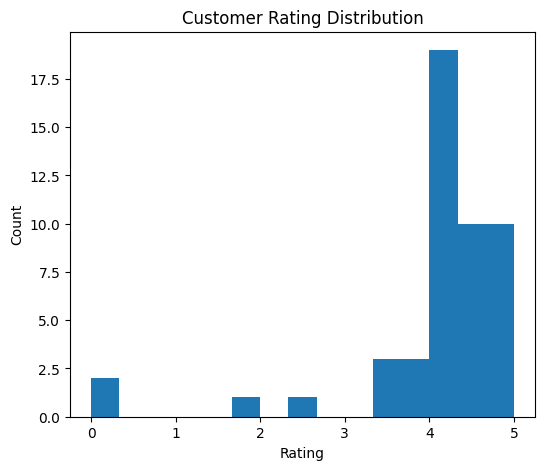

In [36]:
plt.figure(figsize=(6,5))
plt.hist(df["Customer_Rating"], bins = 15)
plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

### Units Sold Over Time

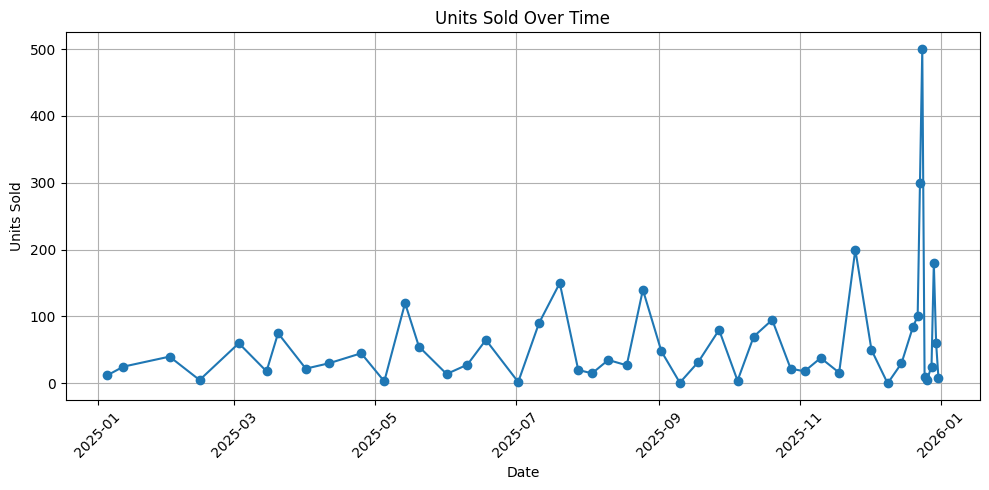

In [37]:
df["Date"] = pd.to_datetime(df["Date"])

df_sorted = df.sort_values("Date")

daily_units = df_sorted.groupby("Date")["Units_Sold"].sum()


plt.figure(figsize=(10,5))
plt.plot(daily_units.index, daily_units.values, marker='o')

plt.title("Units Sold Over Time")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()


### Return Behavior

In [39]:
df.columns

Index(['Order_ID', 'Date', 'City', 'Sales_Rep', 'Product_Category',
       'Product_Name', 'Season', 'Units_Sold', 'Unit_Price_USD',
       'Discount_Percent', 'Revenue_USD', 'Customer_Rating', 'Delivery_Days',
       'Payment_Method', 'Returned'],
      dtype='object')

In [42]:
rate_by_ret = df.groupby("Returned")["Customer_Rating"].mean()

In [43]:
rate_by_ret

Returned
No     4.312195
Yes    2.787500
Name: Customer_Rating, dtype: float64

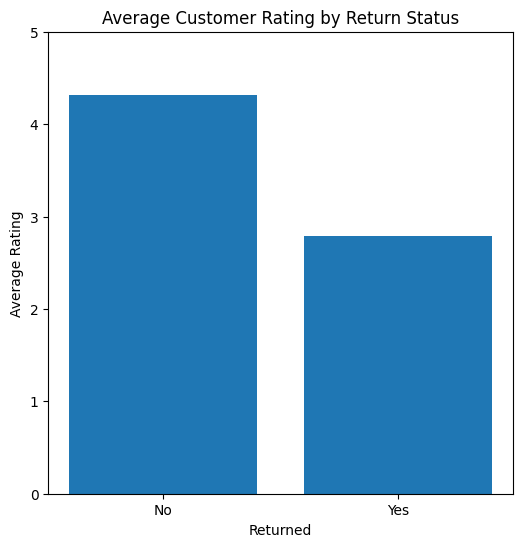

In [44]:
plt.figure(figsize=(6,6))
plt.bar(rate_by_ret.index.astype(str), rate_by_ret.values)
plt.title("Average Customer Rating by Return Status")
plt.xlabel("Returned")
plt.ylabel("Average Rating")
plt.ylim(0,5)
plt.show()

### Return Behavior VS Category

In [47]:
return_cat = df.groupby("Product_Category")["Returned"].value_counts()
return_cat

Product_Category  Returned
Accessories       No          15
Audio             No           8
                  Yes          8
Computer          No          18
Name: count, dtype: int64

In [48]:
return_cat_pivot = return_cat.unstack()
return_cat_pivot

Returned,No,Yes
Product_Category,,
Accessories,15.0,NaN
Audio,8.0,8.0
Computer,18.0,NaN


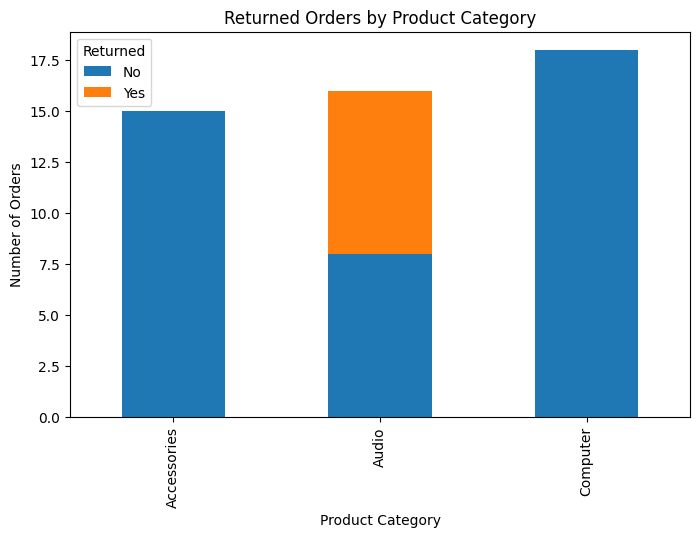

In [49]:
return_cat_pivot.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Returned Orders by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Orders")
plt.legend(title="Returned")
plt.show()

### Delivery Performance

In [51]:
delv_by_ret = df.groupby("Delivery_Days")["Customer_Rating"].mean()
delv_by_ret

Delivery_Days
1.00     3.650000
2.00     4.433333
3.00     3.844444
4.00     4.127273
4.75     4.100000
5.00     4.277778
6.00     4.257143
7.00     4.800000
8.00     4.900000
9.00     4.900000
10.00    4.800000
12.00    0.000000
15.00    1.800000
Name: Customer_Rating, dtype: float64

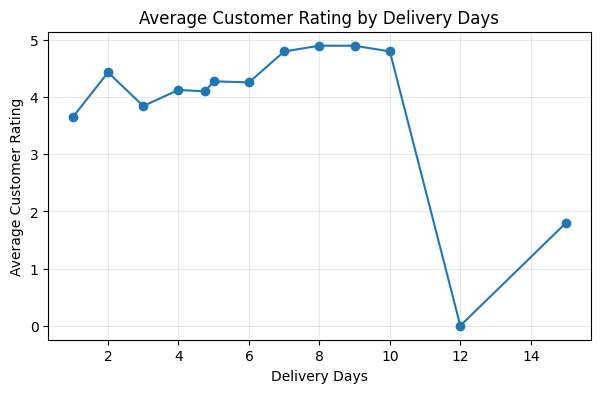

In [52]:
plt.figure(figsize=(7,4))
plt.plot(delv_by_ret.index, delv_by_ret.values, marker='o')
plt.title("Average Customer Rating by Delivery Days")
plt.xlabel("Delivery Days")
plt.ylabel("Average Customer Rating")
plt.grid(alpha=0.3)
plt.show()